In [1]:
import os
import sys
print(sys.executable)
import numpy as np
import pandas as pd
import scipy
import torch
from sklearn import metrics

import pickle
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
import itertools
from tqdm import tqdm
import importlib
import utils

warnings.filterwarnings('ignore')

/admin/software/anaconda/1.11.1/envs/jupyter/bin/python


In [2]:
importlib.reload(utils)
from utils import *

In [3]:
%matplotlib inline

In [4]:
ct = 'BRCA-14AD76EE-12F9-40B3-8DCD-4A256E02CF8D-X002-S03-B1-T1_H3K27ac' # ground truth hichip
#GBMx-09C0DCE7-D669-4D28-980D-BF71179116A4-X019-S06-B1-T1_H3K27ac
#GBMx-6BEE2CB6-9AFD-42A6-9C26-9C4428FBABFA-X009-S04-B1-T1_H3K27ac
#GBMx-9976F952-23A5-431A-A431-01E544324A26-X015-S02-B1-T1_H3K27ac
#GBMx-A90B18B6-6056-46D1-BF4E-70710236B8DD-X015-S07-B1-T1_H3K27ac
#GBM_s320
#GBM_s810
#GBM_s1206

#BRCA-5C54B79C-DA02-4B22-9FC2-3D61BFFC5559-X004-S02-B1-T1_H3K27ac LumA1
#BRCA-7C6A3AE4-E2EA-42B3-B3F1-81C19E6F2170-X004-S01-B1-T1_H3K27ac Basal1
#BRCA-8D1E6006-85CB-484A-8B5C-30766D90137B-X005-S02-B1-T1_H3K27ac
#BRCA-14AD76EE-12F9-40B3-8DCD-4A256E02CF8D-X002-S03-B1-T1_H3K27ac
#BRCA-94AF19F0-1F2A-41EC-8CB6-96C76227811F-X003-S01-B1-T1_H3K27ac Her2
#BRCA-08499A64-3FD8-4E62-AF08-3C66AF93CAE7-X004-S03-B1-T1_H3K27ac
#BRCA-C9C8D426-A3FD-4455-89A9-768BC01D66A9-X003-S02-B1-T1_H3K27ac
#BRCA-C147AAD5-A8F1-41D5-8709-21820BE50902-X005-S01-B1-T1_H3K27ac
#BRCA-CB96A542-7AC1-4FEC-A5D2-458D8EEDC6C4-X001-S01-B1-T1_H3K27ac
#BRCA-DD69EDE9-142D-46E2-AA06-58D07D3230FB-X002-S04-B1-T1_H3K27ac
ct2 = 'BRCA_14AD76EE_12F9_40B3_8DCD_4A256E02CF8D_X003_S02_B1_T1' # predicted mat
#GBMx_A90B18B6_6056_46D1_BF4E_70710236B8DD_X006_S04_B1_T1
#BRCA_94AF19F0_1F2A_41EC_8CB6_96C76227811F_X013_S01_B1_T1
#BRCA_14AD76EE_12F9_40B3_8DCD_4A256E02CF8D_X003_S02_B1_T1
#BRCA_8D1E6006_85CB_484A_8B5C_30766D90137B_X001_S01_B1_T1
#BRCA_C147AAD5_A8F1_41D5_8709_21820BE50902_X008_S02_B1_T1
#BRCA_DD69EDE9_142D_46E2_AA06_58D07D3230FB_X014_S08_B1_T1
#BRCA_08499A64_3FD8_4E62_AF08_3C66AF93CAE7_X009_S01_B1_T1
#BRCA_5C54B79C_DA02_4B22_9FC2_3D61BFFC5559_X011_S02_B1_T1
#BRCA_7C6A3AE4_E2EA_42B3_B3F1_81C19E6F2170_X005_S02_B1_T1
#BRCA_C9C8D426_A3FD_4455_89A9_768BC01D66A9_X009_S02_B1_T1
#BRCA_CB96A542_7AC1_4FEC_A5D2_458D8EEDC6C4_X013_S06_B1_T1
genome = 'hg38'
mod = 'chromafold_CTCFmotif'

In [78]:
zscore_path = (
    "/data1/lesliec/carolw/projects/chromafold/preprocess/GBM-chan/hic_GSC/"
    f"{ct}/zvalue/{ct}_hic_zscore_dict.p"
)

pval_path = (
    "/data1/lesliec/carolw/projects/chromafold/preprocess/GBM-chan/hic_GSC/"
    f"{ct}/qvalue/{ct}_hic_qvalue_dict.p"
)

with open(zscore_path, "rb") as f:
    hicdc = pickle.load(f)

with open(pval_path, "rb") as f:
    pval = pickle.load(f)

In [5]:
# Load Hi-C data for evaluation

zscore_path = (
    "/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/hichip/"
    f"{ct}/zvalue/{ct}_hic_zscore_dict.p"
)

pval_path = (
    "/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/hichip/"
    f"{ct}/qvalue/{ct}_hic_qvalue_dict.p"
)

with open(zscore_path, "rb") as f:
    hicdc = pickle.load(f)

with open(pval_path, "rb") as f:
    pval = pickle.load(f)
    
#hicdc = pickle.load(open("/data1/lesliec/carolw/projects/chromafold/preprocess/GBM-chan/hichip/{}/zvalue/{}_hic_zscore_dict.p".format(ct), "rb"))
#pval = pickle.load(open("/data1/lesliec/carolw/projects/chromafold/preprocess/GBM-chan/hichip/{}/qvalue/{}_hic_qvalue_dict.p".format(ct), "rb"))


In [139]:
# Load input data for visualization
ctcf_motif = pickle.load(open("/data1/lesliec/carolw/repos/ChromaFold/{}_ctcf_motif_score.p".format(genome), 'rb'))
atac = pickle.load(open("/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/atac/{}_tile_pbulk_50bp_dict.p".format(ct2), 'rb'))
scatac = pickle.load(open("/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/atac/{}_tile_500bp_dict.p".format(ct2), 'rb'))
metacell_path = pd.read_csv('/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/atac/{}_metacell_mask.csv'.format(ct2), index_col= 0).values
scatac = get_metacell_profile(scatac, metacell_path)


In [6]:
chrom = list(scatac.keys())[0]
print("Tile matrix shape:", scatac[chrom].shape)


Tile matrix shape: (43, 117236)


# Quantitative Evaluation

In [6]:
hub_coordinates_df = read_and_parse_coordinates("/data1/lesliec/carolw/data_raw/chromafold_metadata/hub_coordinates_chromafold.csv")

In [11]:
#chrom_list = [str(i) for i in range(1, 23)]
#chrom_list = ["1", "14","17","20","3","6","8"]
chrom_list = ["17"]

results = evaluate_predictions_by_chrom(
    chrom_list,
    hicdc=hicdc,
    pval=pval,
    ct2=ct2,
    mod=mod,
    pred_base_path=f"/data1/lesliec/carolw/projects/chromafold/predictions/BRCA-chan_1_3k/{ct2}",
    plot=False
)


===== Chromosome 17 =====


100%|████████████████████████████████████| 7819/7819 [00:00<00:00, 17194.57it/s]


In [24]:
for chrom, vals in results["pearson"].items():
    print(f"chr{chrom}: Pearson={np.nanmean(vals):.4f}, Spearman={np.nanmean(results['spearman'][chrom]):.4f}, AUROC={np.nanmean(results['roc'][chrom]):.4f}, AUPRC={np.nanmean(results['prc'][chrom]):.4f}")

chr1: Pearson=0.3204, Spearman=0.1230, AUROC=0.7258, AUPRC=0.2802
chr14: Pearson=0.2272, Spearman=-0.0962, AUROC=0.7133, AUPRC=0.2442
chr17: Pearson=0.2399, Spearman=0.1780, AUROC=0.6718, AUPRC=0.2302
chr20: Pearson=0.3590, Spearman=0.2931, AUROC=0.7273, AUPRC=0.2802
chr3: Pearson=0.3283, Spearman=0.2353, AUROC=0.7049, AUPRC=0.2630
chr6: Pearson=0.3292, Spearman=0.2752, AUROC=0.7151, AUPRC=0.2665
chr8: Pearson=0.3762, Spearman=0.2658, AUROC=0.7357, AUPRC=0.3131


In [122]:
distance_groups = {
    "10kb-650kb":   (1,   65),
    "650kb-1250kb": (65, 125),
    "1250kb-2MB":  (125, 200),
}

for chrom, vals in results["pearson"].items():
    print(f"\n=== chr{chrom} ===")
    valid_diags = results["valid_diags"][chrom]
    for group_name, (d_start, d_end) in distance_groups.items():
        mask = [d_start <= d <= d_end for d in valid_diags]
        pearson  = np.nanmean([v for v, m in zip(results["pearson"][chrom],  mask) if m])
        spearman = np.nanmean([v for v, m in zip(results["spearman"][chrom], mask) if m])
        roc      = np.nanmean([v for v, m in zip(results["roc"][chrom],      mask) if m])
        prc      = np.nanmean([v for v, m in zip(results["prc"][chrom],      mask) if m])
        print(f"  {group_name}: Pearson={pearson:.4f}, Spearman={spearman:.4f}, AUROC={roc:.4f}, AUPRC={prc:.4f}")


=== chr1 ===
  10kb-650kb: Pearson=0.3962, Spearman=0.2607, AUROC=0.7873, AUPRC=0.3550
  650kb-1250kb: Pearson=0.2451, Spearman=0.1435, AUROC=0.6831, AUPRC=0.2241
  1250kb-2MB: Pearson=0.2022, Spearman=0.1374, AUROC=0.6532, AUPRC=0.1865

=== chr14 ===
  10kb-650kb: Pearson=0.3776, Spearman=-0.1475, AUROC=0.7829, AUPRC=0.4737
  650kb-1250kb: Pearson=0.2077, Spearman=-0.3780, AUROC=0.7409, AUPRC=0.2197
  1250kb-2MB: Pearson=0.1123, Spearman=-0.4033, AUROC=0.7215, AUPRC=0.1060

=== chr17 ===
  10kb-650kb: Pearson=0.3938, Spearman=0.3086, AUROC=0.7517, AUPRC=0.3198
  650kb-1250kb: Pearson=0.2530, Spearman=0.1692, AUROC=0.6416, AUPRC=0.2248
  1250kb-2MB: Pearson=0.1869, Spearman=0.1766, AUROC=0.6303, AUPRC=0.1710

=== chr20 ===
  10kb-650kb: Pearson=0.4741, Spearman=0.2922, AUROC=0.7975, AUPRC=0.3911
  650kb-1250kb: Pearson=0.2719, Spearman=0.1581, AUROC=0.6735, AUPRC=0.2484
  1250kb-2MB: Pearson=0.2071, Spearman=0.1461, AUROC=0.6508, AUPRC=0.1789

=== chr3 ===
  10kb-650kb: Pearson=0.4394

# Visualize

In [8]:
chrom_sizes = pd.read_csv(
    "/data1/lesliec/carolw/genome/hg38/hg38.chrom.sizes",
    sep="\t",
    header=None,
    names=["chr", "size"]
)
chrom_size_dict = {
    (k if k.startswith("chr") else f"chr{k}"): v
    for k, v in zip(chrom_sizes["chr"], chrom_sizes["size"])
}
plot_region=generate_plot_regions(hub_coordinates_df,chrom_size_dict)

Region chr20:46158242-48158242 (hub BRCA_ecDNA) already included in chr20:46145948-48145948
Region chr20:47045999-49045999 (hub BRCA_ecDNA) already included in chr20:46145948-48145948
Region chr20:54721887-56721887 (hub BRCA_ecDNA) already included in chr20:53574095-55574095
Skipping BRCA_ecDNA (chr20:55865560-59474024) — too close to chromosome end
Skipping BRCA_ecDNA (chr20:59474084-60270790) — too close to chromosome end
Skipping BRCA_ecDNA (chr20:63657380-63658047) — too close to chromosome end
Skipping BRCA_ecDNA (chr20:63664881-63665641) — too close to chromosome end
Region chr17:61074410-63074410 (hub BRCA_ecDNA) already included in chr17:59917253-61917253
Region chr17:61137084-63137084 (hub BRCA_ecDNA) already included in chr17:59917253-61917253


In [116]:
SFRP1_start = 41_259_962
SFRP1_end   = 41_311_473
SFRP1_mid   = (SFRP1_start + SFRP1_end) / 2   # 39708376.0

SFRP1_row = {
    "chr"                     : "chr8",
    "ext_start"               : int(SFRP1_mid - 1e6),   # 38708376
    "ext_end"                 : int(SFRP1_mid + 1e6),   # 40708376
    "hub_plotted_coordinates" : "SFRP1:chr8:41,259,962-41,311,473"
}

plot_region = pd.concat(
    [plot_region, pd.DataFrame([SFRP1_row])],
    ignore_index = True
)
plot_region

,chr,ext_start,ext_end,hub_plotted_coordinates
0,chr6,42912072,44912072,VEGFA:chr6:43565123-44259021
1,chr8,37436648,39436648,FGFR1:chr8:37728774-39144522
2,chr14,60638854,62638854,HIF1A:chr14:61441732-61835977
3,chr17,71354160,73354160,SOX9:chr17:71870970-72837350
4,chr3,166766259,168766259,GOLIM4:chr3:167360706-168171813
5,chr20,46145948,48145948,BRCA_ecDNA:chr20:47141442-47150454
6,chr20,49344821,51344821,BRCA_ecDNA:chr20:49875601-50814042
7,chr20,53574095,55574095,BRCA_ecDNA:chr20:53565247-55582944
8,chr17,57840698,59840698,BRCA_ecDNA:chr17:58558971-59122425
9,chr17,59917253,61917253,BRCA_ecDNA:chr17:59829565-62004942


In [9]:

erbb2_start = 39_686_094
erbb2_end   = 39_730_658
erbb2_mid   = (erbb2_start + erbb2_end) / 2   # 39708376.0

erbb2_row = {
    "chr"                     : "chr6",
    "ext_start"               : int(erbb2_mid - 1e6),   # 38708376
    "ext_end"                 : int(erbb2_mid + 1e6),   # 40708376
    "hub_plotted_coordinates" : "ERBB2:chr17:39686094-39730658"
}

plot_region = pd.concat(
    [plot_region, pd.DataFrame([erbb2_row])],
    ignore_index = True
)
plot_region

,chr,ext_start,ext_end,hub_plotted_coordinates
0,chr6,42912072,44912072,VEGFA:chr6:43565123-44259021
1,chr8,37436648,39436648,FGFR1:chr8:37728774-39144522
2,chr14,60638854,62638854,HIF1A:chr14:61441732-61835977
3,chr17,71354160,73354160,SOX9:chr17:71870970-72837350
4,chr3,166766259,168766259,GOLIM4:chr3:167360706-168171813
5,chr20,46145948,48145948,BRCA_ecDNA:chr20:47141442-47150454
6,chr20,49344821,51344821,BRCA_ecDNA:chr20:49875601-50814042
7,chr20,53574095,55574095,BRCA_ecDNA:chr20:53565247-55582944
8,chr17,57840698,59840698,BRCA_ecDNA:chr17:58558971-59122425
9,chr17,59917253,61917253,BRCA_ecDNA:chr17:59829565-62004942


In [12]:

row = plot_region.iloc[9]
chrom = row["chr"]
chrom_num = chrom.replace("chr", "")
yhat = results["yhat"][chrom_num]


In [13]:
# build predicted matrix
pred_mat = get_combined_yhat(
        yhat[:, 0, :],
        start_ind=0,
        end_ind=yhat.shape[0],
        avg_stripe=True
    )



100%|████████████████████████████████████| 7819/7819 [00:00<00:00, 23248.20it/s]


Region: chr17:59917253-61917253 → bins [5991, 6191]


100%|████████████████████████████████████| 7819/7819 [00:00<00:00, 23364.39it/s]


Valid diagonals: 199/199
Mean Pearson:  0.2085
Mean Spearman: 0.0777
Mean AUROC:    0.6314
Mean AUPRC:    0.2908


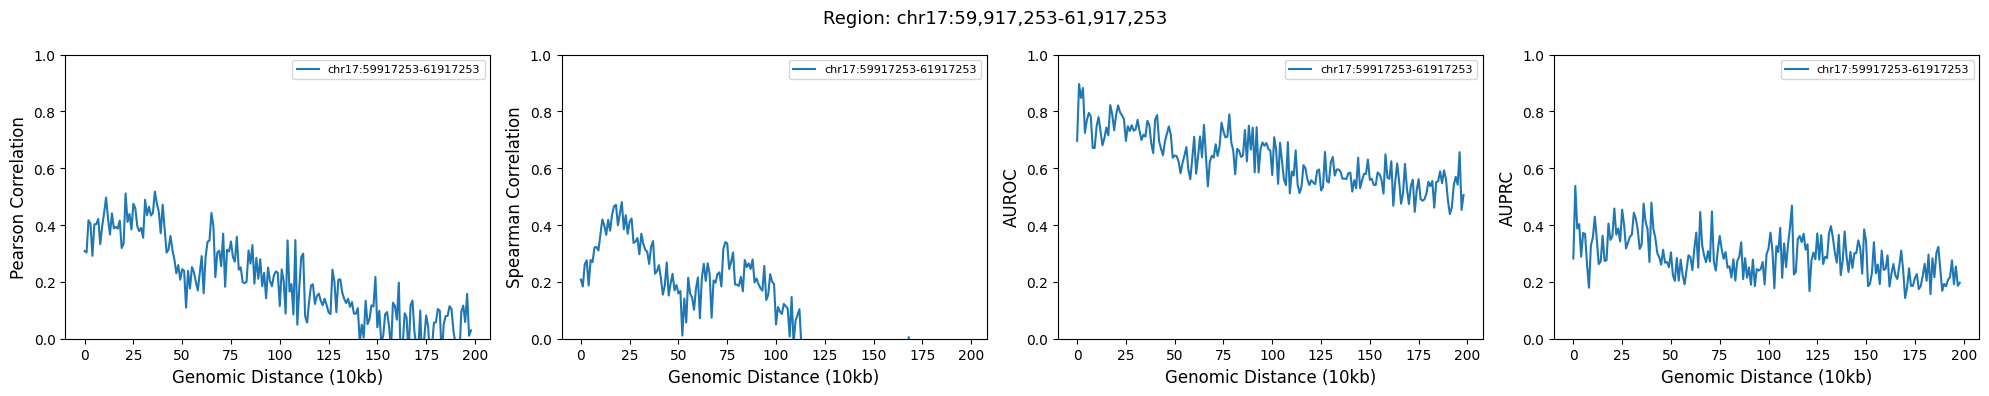

In [14]:
region_results = evaluate_predictions_by_region(
    eval_output=results,   # output from evaluate_predictions_by_chrom
    hicdc=hicdc,
    chrom=chrom_num,
    start=row["ext_start"],
    end=row["ext_end"],
    bin_size=10_000
)

In [126]:

distance_groups = {
    "10kb-650kb":   (1,   65),
    "650kb-1250kb": (65, 125),
    "1250kb-2MB":  (125, 200),
}

for group_name, (d_start, d_end) in distance_groups.items():
    # Diagonals are 1-indexed, list is 0-indexed
    idx = slice(d_start - 1, d_end - 1)
    print(f"\n--- {group_name} ---")
    for metric in ["pearson", "spearman", "roc", "prc"]:
        vals = region_results[metric][idx]
        if vals:
            print(f"  {metric}: {np.nanmean(vals):.4f}")
        else:
            print(f"  {metric}: N/A")


--- 10kb-650kb ---
  pearson: 0.3803
  spearman: 0.3402
  roc: 0.7264
  prc: 0.4057

--- 650kb-1250kb ---
  pearson: 0.4634
  spearman: 0.1732
  roc: 0.7175
  prc: 0.4216

--- 1250kb-2MB ---
  pearson: 0.4011
  spearman: -0.0152
  roc: 0.7515
  prc: 0.4697


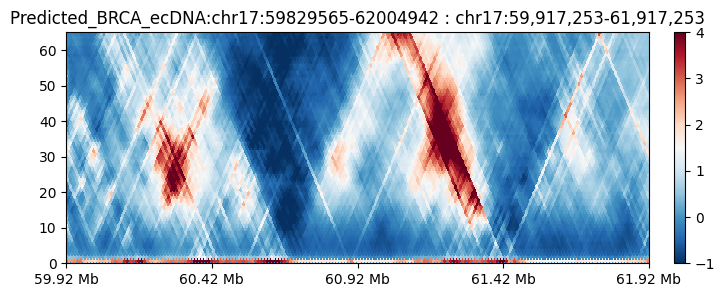

In [15]:
plot_hic_region(
    mat=pred_mat,
    chrom=row["chr"],
    ext_start=row["ext_start"],
    ext_end=row["ext_end"],
    hub_plotted_coordinates=row["hub_plotted_coordinates"],
    title_prefix="Predicted"
)

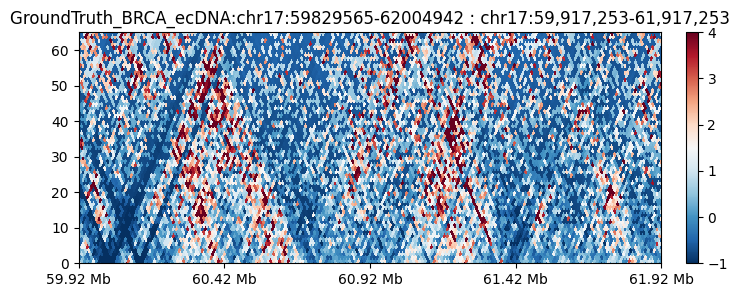

In [16]:
hicdc_mat_chr = hicdc[f"chr{chrom_num}"].toarray()

plot_hic_region(
    mat=hicdc_mat_chr,
    chrom=row["chr"],
    ext_start=row["ext_start"],
    ext_end=row["ext_end"],
    hub_plotted_coordinates=row["hub_plotted_coordinates"],
    title_prefix="GroundTruth"
)

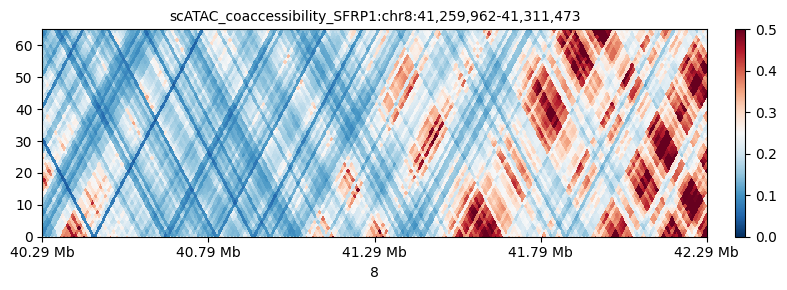

In [145]:
plot_scatac_coaccessibility(
    scatac=scatac,
    chrom=chrom_num,
    ext_start=row["ext_start"],
    ext_end=row["ext_end"],
    hub_plotted_coordinates=row["hub_plotted_coordinates"]
)

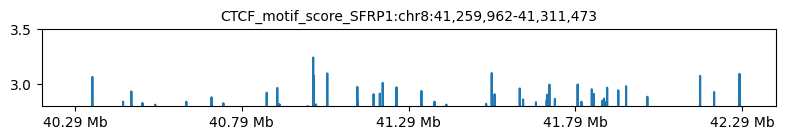

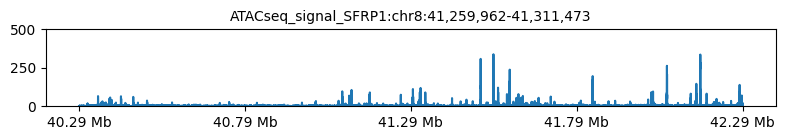

In [146]:
plot_atac_ctcf(
    ctcf_motif=ctcf_motif,
    atac=atac,
    chrom=chrom_num,
    ext_start=row["ext_start"],
    ext_end=row["ext_end"],
    hub_plotted_coordinates=row["hub_plotted_coordinates"]
)

In [124]:
import coolbox
from coolbox.api import *
import matplotlib.pyplot as plt

In [125]:
frame = XAxis() + GTF("/data1/lesliec/carolw/genome/hg38/gencode.v49.annotation.gtf", 
                      length_ratio_thresh = 0.005, fontsize = 32) + TrackHeight(4)

[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.
[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


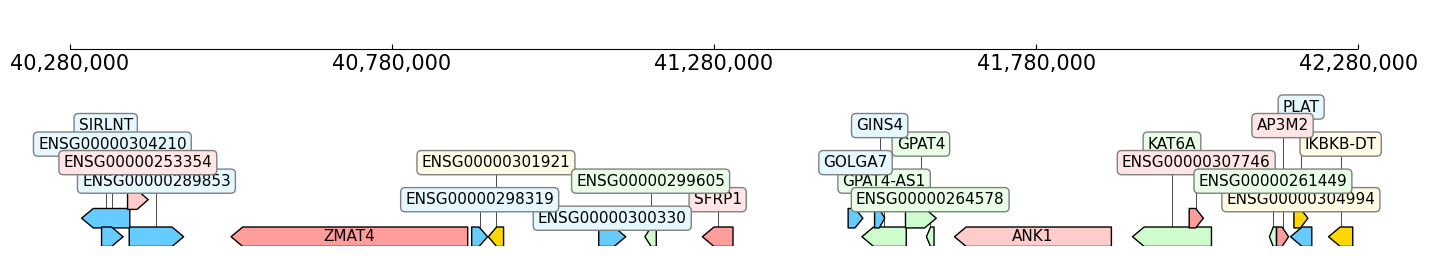

In [126]:
start_bin=row["ext_start"]// 10_000 
end_bin=row["ext_end"]// 10_000 

start = start_bin * 200 * 50
end = end_bin * 200 * 50
TEST_RANGE = "{}:{}-{}".format(chrom, start, end)

#frame.plot(TEST_RANGE)
fig = frame.plot(TEST_RANGE)

tick_positions = np.linspace(start, end, 5).astype(int)
for ax in fig.axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{x:,}" for x in tick_positions], fontsize=10)

fig

[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.
[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


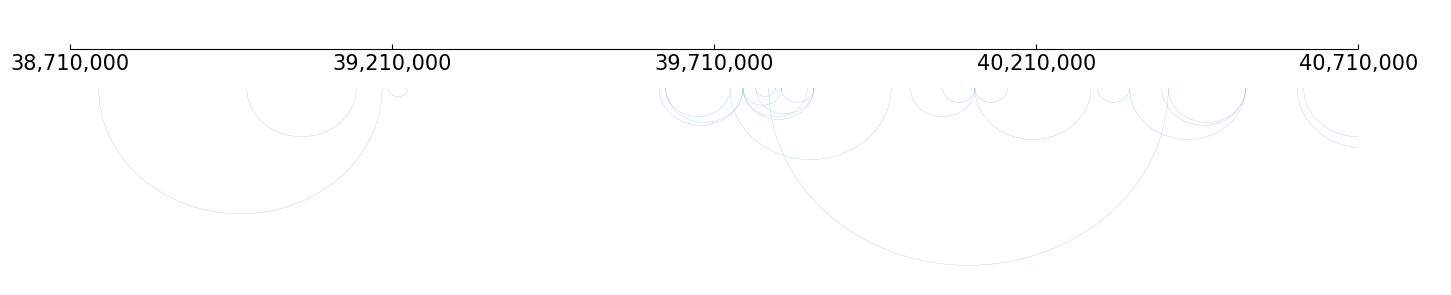

In [10]:

ct="BRCA-7C6A3AE4-E2EA-42B3-B3F1-81C19E6F2170-X004-S01-B1-T1_H3K27ac"
peak_dir= f"/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/hichip/{ct}"
frame = XAxis() + Arcs(f"{peak_dir}/{ct}_hg38_10kb_GATC_GANTC_FDR_05_norm_65bins.bedpe", line_width = 0.15) + Inverted()+ TrackHeight(5)
#frame.plot(f"chr{chrom}:{start}-{end}")
fig = frame.plot(TEST_RANGE)

tick_positions = np.linspace(start, end, 5).astype(int)
for ax in fig.axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{x:,}" for x in tick_positions], fontsize=10)

fig


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.
[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


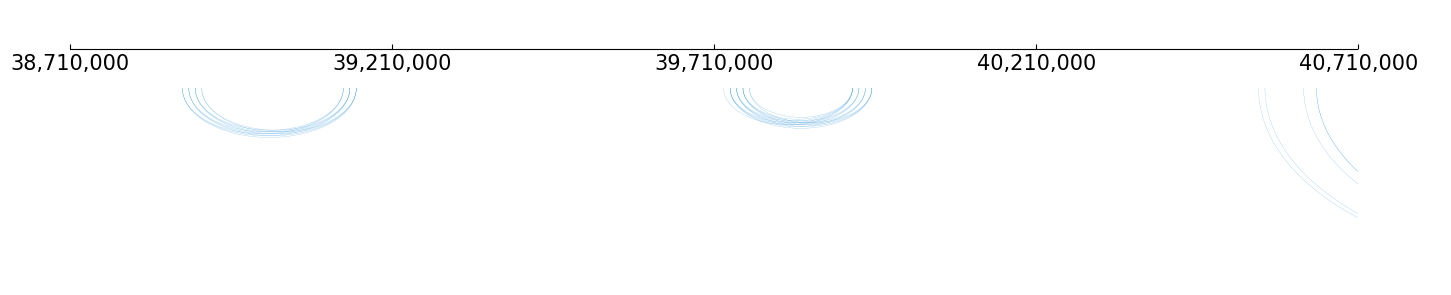

In [110]:
#ct2="GBMx_immuneCells"
frame = XAxis() + Arcs(f"/data1/lesliec/carolw/projects/chromafold/predictions/BRCA-chan_1_3k/bedpe_files/{ct2}_chrom17_co5_10kb.bedpe", line_width = 0.15) + Inverted()+ TrackHeight(5)
#frame.plot(f"chr{chrom}:{start}-{end}")
fig = frame.plot(TEST_RANGE)

tick_positions = np.linspace(start, end, 5).astype(int)
for ax in fig.axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{x:,}" for x in tick_positions], fontsize=10)

fig
